<a href="https://colab.research.google.com/github/abdulkhakam/porto-exploratory-data-analys-movie-data-/blob/main/movie_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
movies_data = pd.read_csv("/content/movies_metadata.csv", engine='python', on_bad_lines='skip')

In [ ]:
movies_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10255 entries, 0 to 10254
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  10255 non-null  bool   
 1   belongs_to_collection  1443 non-null   object 
 2   budget                 10255 non-null  int64  
 3   genres                 10255 non-null  object 
 4   homepage               695 non-null    object 
 5   id                     10255 non-null  int64  
 6   imdb_id                10254 non-null  object 
 7   original_language      10255 non-null  object 
 8   original_title         10255 non-null  object 
 9   overview               10225 non-null  object 
 10  popularity             10255 non-null  float64
 11  poster_path            10223 non-null  object 
 12  production_companies   10255 non-null  object 
 13  production_countries   10255 non-null  object 
 14  release_date           10250 non-null  object 
 15  re

In [ ]:
movies_data.sample(10)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
8237,False,NaN,0,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...",NaN,47959,tt0274407,en,Callas Forever,A fictionalized account of the last days of op...,...,2002-09-18,0,111.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Callas Forever,False,6.0,5
5327,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,26290,tt0263725,en,Me Without You,"During a long, hot summer in seventies London,...",...,2001-11-01,0,107.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,...best friends forever?,Me Without You,False,7.1,19
1323,False,"{'id': 151, 'name': 'Star Trek: The Original S...",27000000,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",NaN,174,tt0102975,en,Star Trek VI: The Undiscovered Country,"On the eve of retirement, Kirk and McCoy are c...",...,1991-12-05,96900000,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The battle for peace has begun.,Star Trek VI: The Undiscovered Country,False,6.7,421
1862,False,"{'id': 8581, 'name': 'A Nightmare on Elm Stree...",7000000,"[{'id': 27, 'name': 'Horror'}, {'id': 53, 'nam...",NaN,10131,tt0095742,en,A Nightmare on Elm Street 4: The Dream Master,Dream demon Freddy Krueger is resurrected from...,...,1988-08-19,72500000,99.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Terror beyond your wildest dreams.,A Nightmare on Elm Street 4: The Dream Master,False,5.8,287
8108,False,NaN,20000000,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,15644,tt0338325,en,Paparazzi,A rising Hollywood actor decides to take perso...,...,2004-09-03,16605763,84.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,One good shot deserves another.,Paparazzi,False,5.8,52
4734,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",http://www.imax.com/,45929,tt0105601,en,Titanica,Titanica is a fascinating non-fiction drama wh...,...,1995-04-01,0,95.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"The Unsinkable Ship, The Unthinkable Disaster,...",Titanica,False,6.0,4
3057,False,NaN,82000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://www.universalpictures.com/manonthemoon/,1850,tt0125664,en,Man on the Moon,A film about the life and career of the eccent...,...,1999-12-22,47434430,118.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"Hello, my name is Andy and this is my movie.",Man on the Moon,False,6.9,444
5431,False,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,96218,tt0219756,en,Heartbreak Hospital,The actress Neely break with her boyfriend. Lo...,...,2002-09-06,0,91.0,[],Released,NaN,Heartbreak Hospital,False,0.0,0
200,False,NaN,0,"[{'id': 35, 'name': 'Comedy'}]",NaN,9090,tt0114682,en,"To Wong Foo, Thanks for Everything! Julie Newmar",Three New York drag queens on their way to Hol...,...,1995-09-07,47774193,105.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Attitude is everything,"To Wong Foo, Thanks for Everything! Julie Newmar",False,6.3,117
1131,False,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,10608,tt0103850,en,Bob Roberts,Mock documentary about an upstart candidate fo...,...,1992-09-04,0,102.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Vote first. Ask questions later.,Bob Roberts,False,6.5,44


In [ ]:
movies_data["release_date"] = pd.to_datetime(movies_data["release_date"])

In [ ]:
movies_data["release_date"].dtypes

dtype('<M8[ns]')

In [ ]:
movies_data["status"].unique()

array(['Released', nan, 'Rumored', 'Post Production'], dtype=object)

In [ ]:
movies_data["original_language"].nunique()

47

In [ ]:
#movies_data["status"]=="Released"

In [ ]:
movies_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10255 entries, 0 to 10254
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   adult                  10255 non-null  bool          
 1   belongs_to_collection  1443 non-null   object        
 2   budget                 10255 non-null  int64         
 3   genres                 10255 non-null  object        
 4   homepage               695 non-null    object        
 5   id                     10255 non-null  int64         
 6   imdb_id                10254 non-null  object        
 7   original_language      10255 non-null  object        
 8   original_title         10255 non-null  object        
 9   overview               10225 non-null  object        
 10  popularity             10255 non-null  float64       
 11  poster_path            10223 non-null  object        
 12  production_companies   10255 non-null  object        
 13  p

In [ ]:
movies_data.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173


In [ ]:
movies_data["profit"] = (movies_data["revenue"]-movies_data["budget"])

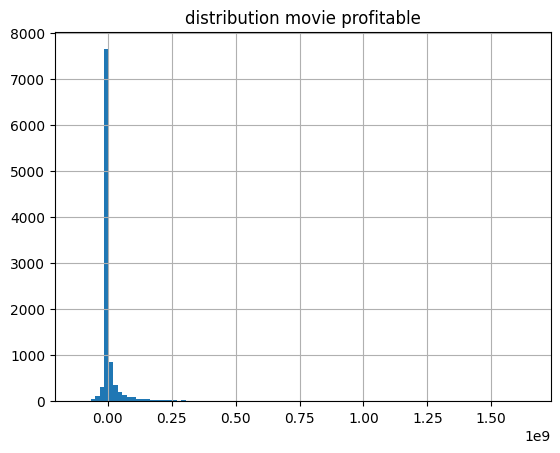

In [ ]:
movies_data["profit"].hist(bins=100)
plt.title ("distribution movie profitable")
plt.show()

In [ ]:
movies_data["profit"].describe()

,profit
count,1.025500e+04
mean,1.340206e+07
std,6.114090e+07
min,-1.191800e+08
25%,0.000000e+00
50%,0.000000e+00
75%,4.587765e+05
max,1.645034e+09


<Axes: >

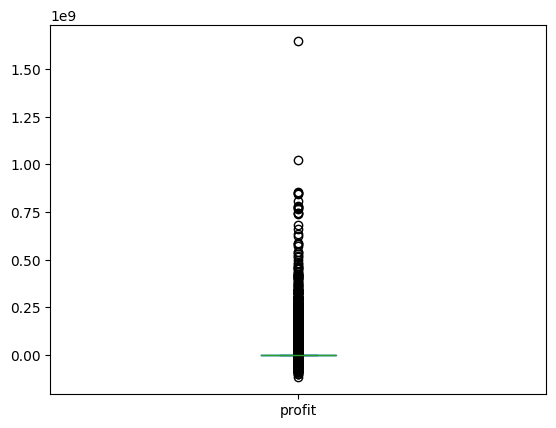

In [ ]:
movies_data["profit"].plot(kind = "box")

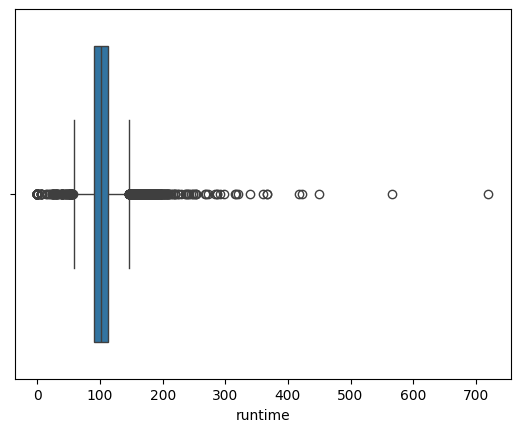

In [ ]:
sns.boxplot(data = movies_data, x = "runtime")
plt.show()

In [ ]:
movies_data["profit"].quantile(0.9)

np.float64(32469983.20000002)

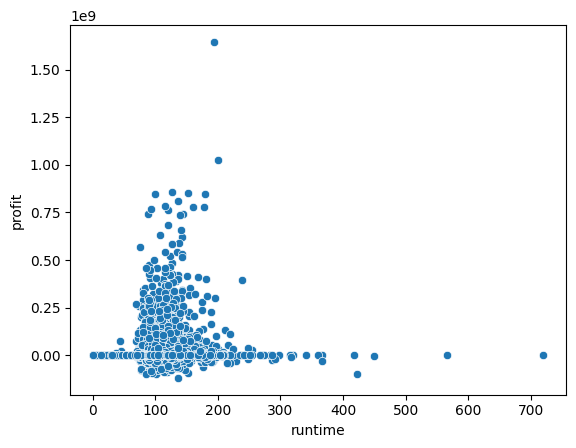

In [ ]:
sns.scatterplot(data = movies_data,
                 x = "runtime",
                  y = "profit")
plt.show()

In [ ]:
profitable_movie = movies_data[movies_data["profit"]>0]

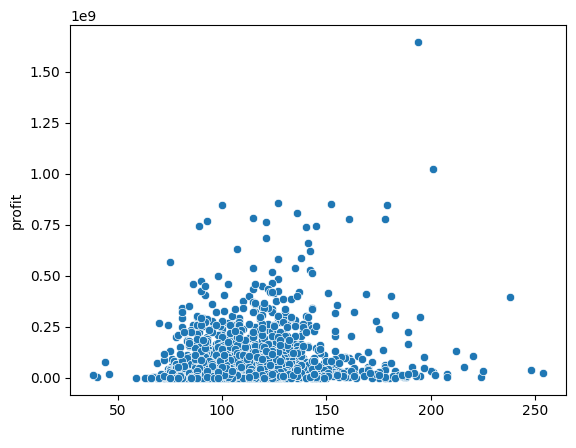

In [ ]:
sns.scatterplot(data = profitable_movie,
                 x = "runtime",
                  y = "profit")
plt.show()

In [ ]:
rating = pd.read_csv("/content/ratings_small.csv")

In [ ]:
rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [ ]:
rating.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [ ]:
rating_movie = rating.groupby("movieId", as_index = False)["rating"].median()

<Axes: xlabel='rating', ylabel='Count'>

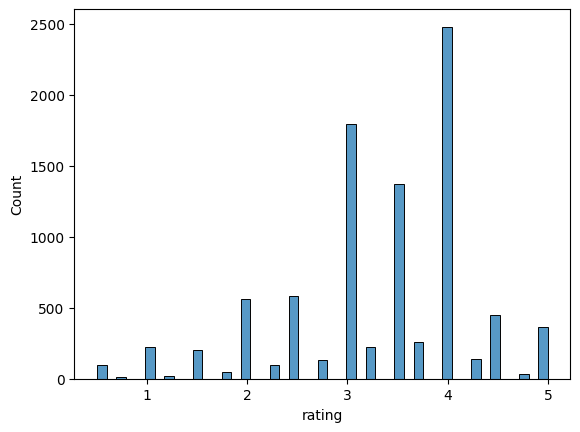

In [ ]:
sns.histplot(data = rating_movie,
             x = "rating")

In [ ]:
rating_movie["good_movie"] = rating_movie["rating"] >= 3

<Axes: xlabel='good_movie'>

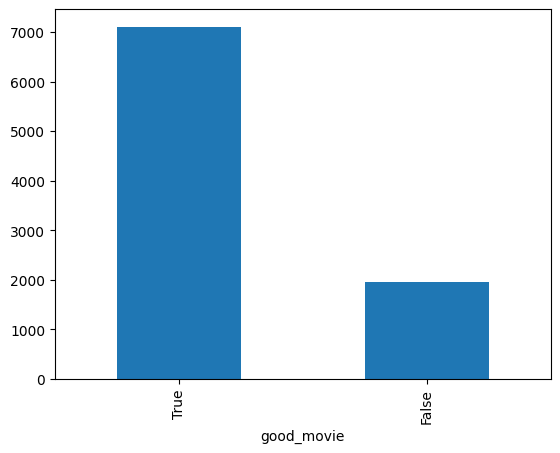

In [ ]:
rating_movie["good_movie"].value_counts().plot(kind = "bar")

In [ ]:
new_df = movies_data.merge(rating_movie,
                          left_on = "id",
                          right_on = "movieId",
                          how = "inner")

<Axes: xlabel='profit', ylabel='Count'>

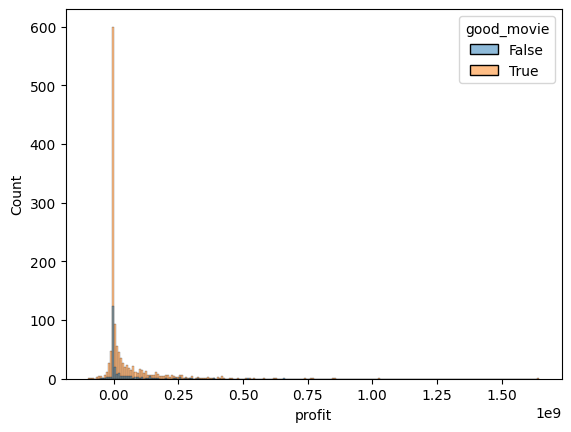

In [ ]:
sns.histplot(data = new_df,
             x = "profit",
             hue = "good_movie")

<Axes: xlabel='rating', ylabel='profit'>

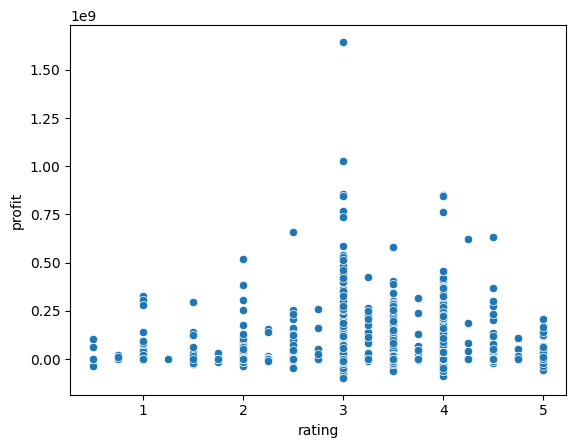

In [ ]:
sns.scatterplot(data = new_df,
                x = "rating",
                y = "profit")

In [ ]:
new_df[["rating"]]

,rating
0,3.75
1,1.50
2,4.00
3,3.50
4,5.00
...,...
1540,2.00
1541,3.00
1542,3.00
1543,4.00


<Axes: xlabel='original_language'>

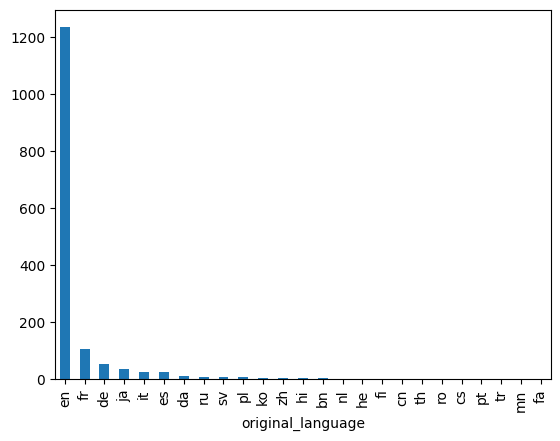

In [ ]:
new_df["original_language"].value_counts().plot(kind = "bar")

In [ ]:
new_df.select_dtypes(include ="number")

,budget,id,popularity,revenue,runtime,vote_average,vote_count,profit,movieId,rating
0,60000000,949,17.924927,187436818,170.0,7.7,1886,127436818,949,3.75
1,58000000,710,14.686036,352194034,130.0,6.6,1194,294194034,710,1.50
2,98000000,1408,7.284477,10017322,119.0,5.7,137,-87982678,1408,4.00
3,52000000,524,10.137389,116112375,178.0,7.8,1343,64112375,524,3.50
4,16500000,4584,10.673167,135000000,136.0,7.2,364,118500000,4584,5.00
...,...,...,...,...,...,...,...,...,...,...
1540,0,1696,12.221507,0,107.0,6.6,329,0,1696,2.00
1541,0,1665,4.790012,1928985,96.0,5.3,95,1928985,1665,3.00
1542,8000000,5237,11.774191,0,103.0,6.7,34,-8000000,5237,3.00
1543,10000000,308,6.589304,45742101,105.0,6.8,359,35742101,308,4.00


In [ ]:
def select_columns(df: pd.DataFrame, features: list, target: list = "rating"):
  df = df.dropna().reset_index(drop=True)
  x = df[features]
  y = (df[target] >= 3).astype("int")

  return x, y

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
features = ["budget", "popularity", "vote_average"]
x, y = select_columns(new_df, features = features)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
minmax = MinMaxScaler()

In [ ]:
minmax.fit(x_train)

MinMaxScaler()

In [ ]:
def scaling(df, scaler):

  # df["runtime"] = df["runtime"].div(60)

  scaled_array = scaler.transform(df)
  scaled_df = pd.DataFrame(scaled_array, columns = scaler.get_features_names_out())

  return scaled_df

In [ ]:
def scaling(df, scaler):
  # df["runtime"] = df["runtime"].div(60)
  scaled_array = scaler.transform(df)
  scaled_df = pd.DataFrame(scaled_array, columns = df.columns)

  return scaled_df

x_train_scaled = scaling(x_train, minmax)
x_test_scaled = scaling(x_test, minmax)

In [ ]:
x_test_scaled.iloc[0]

,0
budget,0.075000
popularity,0.317452
vote_average,0.894737


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 5)
dt = DecisionTreeClassifier()

In [ ]:
knn.fit(x_train_scaled, y_train)
dt.fit(x_train_scaled, y_train)

DecisionTreeClassifier()

In [ ]:
y_train_pred_knn = knn.predict(x_train_scaled)
y_train_pred_dt = dt.predict(x_train_scaled)

In [ ]:
y_test_pred_knn = knn.predict(x_test_scaled)
y_test_pred_dt = dt.predict(x_test_scaled)

In [ ]:
pd.crosstab(y_test, y_test_pred_knn)

col_0,1
rating,
0,1
1,24


In [ ]:
pd.crosstab(y_test, y_test_pred_dt)

col_0,0,1
rating,,
0,0,1
1,4,20
